# 00 - Preprocess, Splits & EDA

**Run once.** Applies the paper's fundus crop and caches it, freezes a stratified 5-fold split, and makes the dataset figures. All model notebooks depend on `manifest_cached.json` and `splits.json` written here.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, glob
# auto-locate the folder that actually contains fundus_lib
hits = glob.glob("/content/drive/MyDrive/**/fundus_lib/__init__.py", recursive=True)
assert hits, "fundus_lib not found anywhere under MyDrive — check the upload"
PROJECT_DIR = os.path.dirname(os.path.dirname(hits[0]))
print("PROJECT_DIR ->", PROJECT_DIR)

DATA_ROOT   = os.path.join(PROJECT_DIR, "1000images")
CACHE_DIR   = os.path.join(PROJECT_DIR, "cache_crops")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
MANIFEST    = os.path.join(PROJECT_DIR, "manifest_cached.json")
SPLITS      = os.path.join(PROJECT_DIR, "splits.json")
os.makedirs(RESULTS_DIR, exist_ok=True)

%pip install -q timm transformers torchinfo grad-cam

sys.path.insert(0, PROJECT_DIR)
import fundus_lib as fl
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| imported fundus_lib OK")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR -> /content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project
device: cuda | imported fundus_lib OK


## 1. Build manifest (bigclasses 0-9, dedup-aware)

In [3]:
manifest = fl.data.build_manifest(DATA_ROOT, keep_bigclasses=range(10))
print("images in bigclasses 0-9:", len(manifest))
from collections import Counter
counts = Counter(m["bigclass"] for m in manifest)
for k in range(10):
    print(f"  {k}: {counts[k]:3d}  {fl.data.bigclass_names[k]}")

images in bigclasses 0-9: 551
  0: 119  Normal / Tessellated / Large optic cup / DR1
  1:  88  DR2-DR3 (moderate-severe NPDR)
  2:  66  BRVO / CRVO
  3:  16  RAO
  4:  57  Rhegmatogenous RD
  5:  28  CSCR / VKH
  6:  74  Maculopathy
  7:  26  ERM
  8:  23  MH
  9:  54  Pathological myopia


## 2. Paper preprocessing -> cached 512px crops (runs only here)

In [4]:
import json
manifest = fl.preprocess.build_cache(manifest, CACHE_DIR, out_size=512)
with open(MANIFEST, "w") as fh:
    json.dump(manifest, fh)
print("saved", MANIFEST, "with", len(manifest), "entries")

  processed 100/551 images
  processed 200/551 images
  processed 300/551 images
  processed 400/551 images
  processed 500/551 images
done: 551 cached, 0 failed
saved /content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/manifest_cached.json with 551 entries


## 3. Freeze stratified 5-fold split

In [5]:
import numpy as np
folds = fl.data.make_splits(manifest, n_splits=5, seed=42, out_path=SPLITS)
print("fold sizes:", [int((folds==f).sum()) for f in range(5)])
print("saved", SPLITS)

fold sizes: [111, 110, 110, 110, 110]
saved /content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/splits.json


## 4. EDA - class distribution

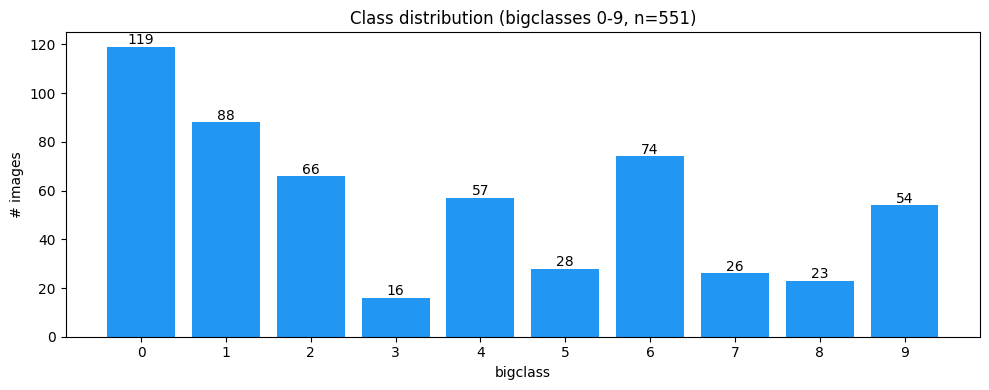

In [6]:
import matplotlib.pyplot as plt
ks = list(range(10)); vals = [counts[k] for k in ks]
plt.figure(figsize=(10,4))
plt.bar([str(k) for k in ks], vals, color="#2196F3")
plt.xlabel("bigclass"); plt.ylabel("# images")
plt.title("Class distribution (bigclasses 0-9, n=%d)" % len(manifest))
for i,v in enumerate(vals): plt.text(i, v+1, str(v), ha="center")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR,"class_distribution.png"), dpi=150); plt.show()

## 5. EDA - raw vs paper-cropped

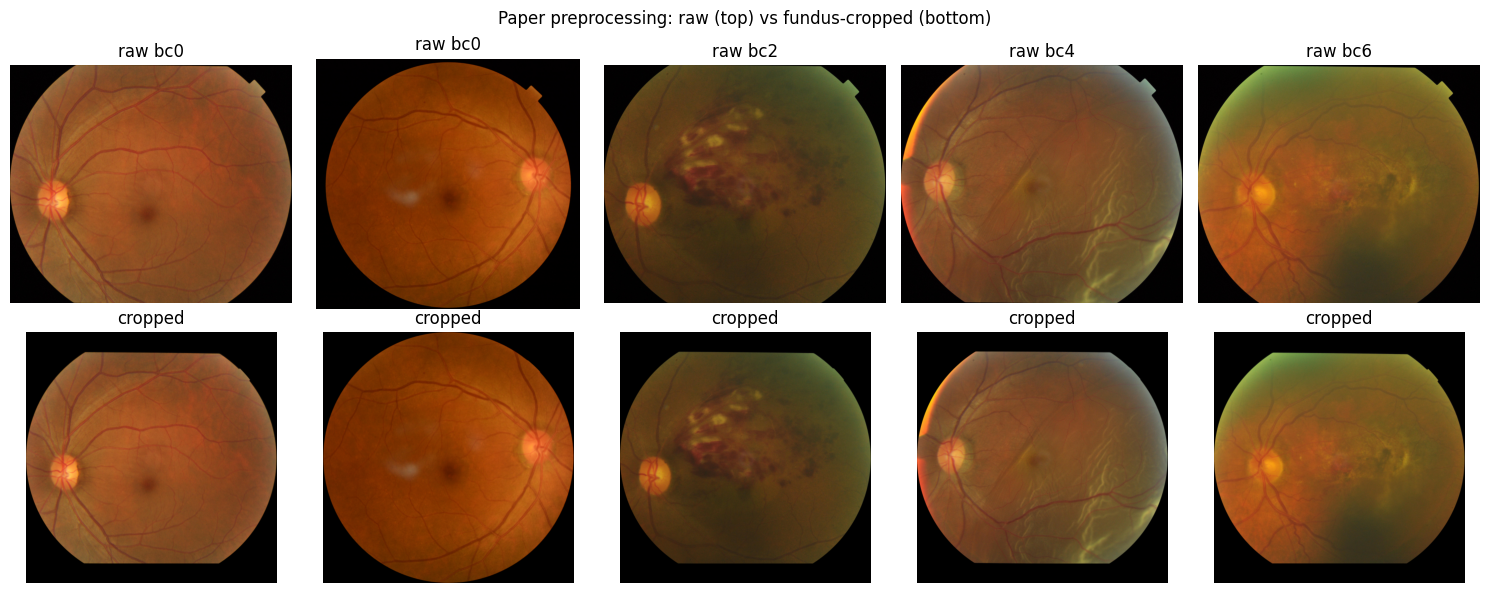

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 5, figsize=(15,6))
for j in range(5):
    row = manifest[j*(len(manifest)//5)]
    ax[0,j].imshow(Image.open(row["path"]).convert("RGB")); ax[0,j].set_title("raw bc%d"%row["bigclass"]); ax[0,j].axis("off")
    ax[1,j].imshow(Image.open(row["cache_path"]).convert("RGB")); ax[1,j].set_title("cropped"); ax[1,j].axis("off")
plt.suptitle("Paper preprocessing: raw (top) vs fundus-cropped (bottom)")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR,"preprocess_examples.png"), dpi=150); plt.show()